# Web-Based Skin Condition Classification System

This notebook contains source code used to train, evaluate and save an EfficientNet-B7 model on a dataset mounted in Google Drive and was submitted alongside a dissertation to Swansea University on April 24th 2026.

## Imports

In [ ]:
from google.colab import drive
import tensorflow as tf
import os
from tensorflow.keras import layers
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import load_model

## Load in Dataset

In [ ]:
drive.mount('/content/drive')

train_path = 'drive/MyDrive/SkinDiseaseNEW/train'
test_path = 'drive/MyDrive/SkinDiseaseNEW/test'

# Define parameters for loading datasets
batch_size = 32
img_height = 600
img_width = 600

# Use TensorFlow to create training set
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_path,
  labels="inferred",
  label_mode="int",
  batch_size=batch_size,
  image_size=(img_height, img_width),
  shuffle=True,
  seed=123,
  validation_split=0.1,
  subset="training",
  interpolation="lanczos5",
  data_format="channels_last"
)

# Use TensorFlow to create validation set
validation_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_path,
  labels="inferred",
  label_mode="int",
  batch_size=batch_size,
  image_size=(img_height, img_width),
  shuffle=True,
  seed=123,
  validation_split=0.1,
  subset="validation",
  interpolation="lanczos5",
  data_format="channels_last"
)

# Use TensorFlow to create testing set
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
  test_path,
  labels="inferred",
  label_mode="int",
  batch_size=batch_size,
  image_size=(img_height,img_width),
  interpolation="lanczos5",
  data_format="channels_last"
)

Mounted at /content/drive
Found 4464 files belonging to 8 classes.
Using 4018 files for training.
Found 4464 files belonging to 8 classes.
Using 446 files for validation.
Found 490 files belonging to 8 classes.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 299, 299, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [ ]:
# Print class names (used to test creation of datasets worked)
print(train_ds.class_names)
print(validation_ds.class_names)
print(test_ds.class_names)

['Acne', 'Bullous', 'Candidiasis', 'Eczema', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'Warts']
['Acne', 'Bullous', 'Candidiasis', 'Eczema', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'Warts']
['Acne', 'Bullous', 'Candidiasis', 'Eczema', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'Warts']


In [ ]:
# To find class imbalances in the training set
for class_name in sorted(os.listdir(train_path)):
    # Adds class_name to end of train_path
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        # Counts number of images in the class folder
        count = len(os.listdir(class_path))
        print(f"{class_name}: {count} images")

Acne: 593 images
Bullous: 504 images
Candidiasis: 248 images
Eczema: 1010 images
Psoriasis: 820 images
Rosacea: 254 images
Seborrh_Keratoses: 455 images
Warts: 580 images


## Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
    layers.RandomTranslation(0.1, 0.1),
])

## Load in Model Architecture and Initial Phase of Training

In [ ]:
# Load the EfficientNet-B7 model pre-trained on ImageNet, excluding the top classification layer
base_model = tf.keras.applications.EfficientNetB7(
    include_top=False,
    weights='imagenet',
    input_shape=(img_height, img_width, 3)
)

# Freeze the base model to prevent weights from being updated during initial training
base_model.trainable = False

# Create input layer of the model
inputs = tf.keras.Input(shape=(img_height, img_width, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)

# Add a final pooling and dropout layer prior to dense layer
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)

# Determine number of classes from the dataset
num_classes = len(train_ds.class_names)

# Create output layer of the model (specific to the number of classes)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']),

model.summary()

# Train the model
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds,
)

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb7 (Functional)     │ (None, 10, 10, 2560)   │    64,097,687 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2560)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2560)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        20,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,118,175 (244.59 MB)

 Trainable params: 20,488 (80.03 KB)

 Non-trainable params: 64,097,687 (244.51 MB)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 138s 808ms/step - accuracy: 0.4572 - loss: 1.4910 - val_accuracy: 0.5583 - val_loss: 1.2424
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.5660 - loss: 1.2181 - val_accuracy: 0.5673 - val_loss: 1.1676
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.5958 - loss: 1.1193 - val_accuracy: 0.5987 - val_loss: 1.0986
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 166ms/step - accuracy: 0.6197 - loss: 1.0781 - val_accuracy: 0.6076 - val_loss: 1.0703
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.6239 - loss: 1.0500 - val_accuracy: 0.6457 - val_loss: 1.0200
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.6329 - loss: 1.0326 - val_accuracy: 0.6480 - val_loss: 1.0157
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.6401 - loss: 0.9993 - val_accuracy: 0.6525 - val_loss: 0.9935
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 165ms/step - accuracy: 0.6473 - loss: 

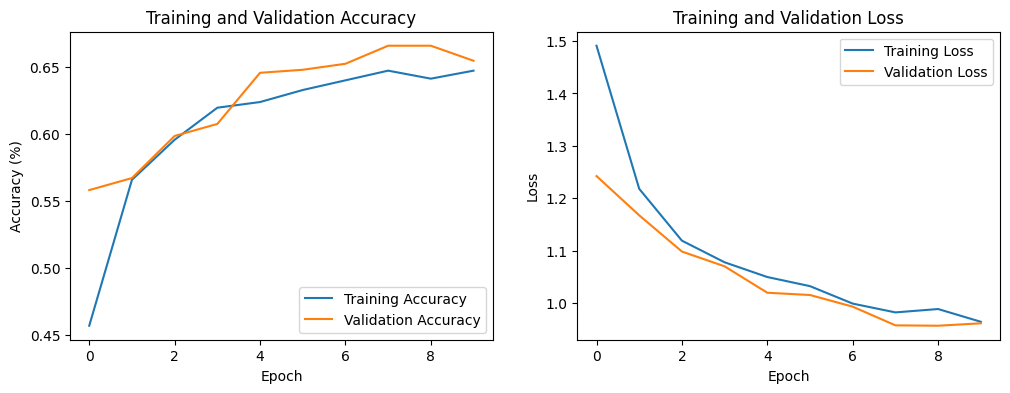

In [ ]:
# Extract the metrics from the history object
accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(len(accuracy))

plt.figure(figsize=(12, 4))

# Plot accuracy curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

# Plot loss curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [ ]:
# Evaluate the model on the testing set
model.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 683ms/step - accuracy: 0.6531 - loss: 0.9791


[0.9791190028190613, 0.6530612111091614]

## Fine-Tuning Phase of Training



In [ ]:
# Unfreeze model's weights
base_model.trainable = True

# Re-freeze layers except the last 20 to preserve general, pre-trained features but allow
# the model to adjust its weights to the new data
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Recompile with a much lower learning rate to protect destroying pre-trained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train the fined-tuned model
history = model.fit(
    train_ds,
    epochs=20,
    validation_data=validation_ds,
    # Uses callbacks to help prevent overfitting
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
        tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_accuracy")
    ]
)

Epoch 1/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 70s 277ms/step - accuracy: 0.6195 - loss: 1.1064 - val_accuracy: 0.6592 - val_loss: 0.9420
Epoch 2/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 201ms/step - accuracy: 0.6334 - loss: 1.0162 - val_accuracy: 0.6659 - val_loss: 0.9375
Epoch 3/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 208ms/step - accuracy: 0.6531 - loss: 0.9740 - val_accuracy: 0.6704 - val_loss: 0.9271
Epoch 4/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 23s 174ms/step - accuracy: 0.6645 - loss: 0.9437 - val_accuracy: 0.6659 - val_loss: 0.9200
Epoch 5/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 25s 200ms/step - accuracy: 0.6660 - loss: 0.9522 - val_accuracy: 0.6771 - val_loss: 0.9014
Epoch 6/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 26s 207ms/step - accuracy: 0.6832 - loss: 0.9040 - val_accuracy: 0.6794 - val_loss: 0.8918
Epoch 7/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 27s 214ms/step - accuracy: 0.6757 - loss: 0.8998 - val_accuracy: 0.6839 - val_loss: 0.8838
Epoch 8/20
126/126 ━━━━━━━━━━━━━━━━━━━━ 23s 175ms/step - accuracy: 0.6757 - loss: 0

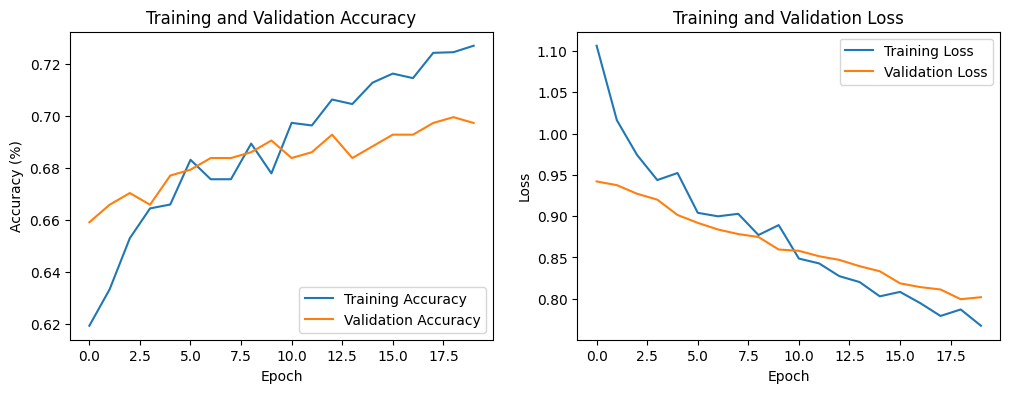

In [ ]:
# Extract the metrics from the history object
accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
loss = history.history['loss']
validation_loss = history.history['val_loss']

epochs_range = range(len(accuracy))

plt.figure(figsize=(12, 4))

# Plot accuracy curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

# Plot loss curves
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, validation_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

In [ ]:
# Evaluate the model on the testing set
model.evaluate(test_ds)

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.7102 - loss: 0.8219


[0.8218514919281006, 0.7102040648460388]

## Evaluation

In [ ]:
# Initialise arrays
y_true = []
y_pred = []

# Get true labels and predictions
for images, labels in test_ds:
    # Use labels to represent ground truths
    y_true.extend(labels.numpy())
    # Make the model generate predictions
    predictions = model.predict(images)
    # Store the class with the highest softmax value in prediction array
    y_pred.extend(np.argmax(predictions, axis=1))

# Get class names from the training dataset
class_names = train_ds.class_names

# Generate classification report
report = classification_report(y_true, y_pred, target_names=class_names, labels=range(len(class_names)))
print(report)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
                   precision    recall  f1-score   support

             Acne       0.83      0.83      0.83        65
          Bullous       0.84      0.69      0.76        55
      Candidiasis       0.75      0.44      0.56        27
           Eczema       0.56      0.78      0.65       112
        Psoriasis       0.62      0.57      0.59        88
          Rosacea       0.9

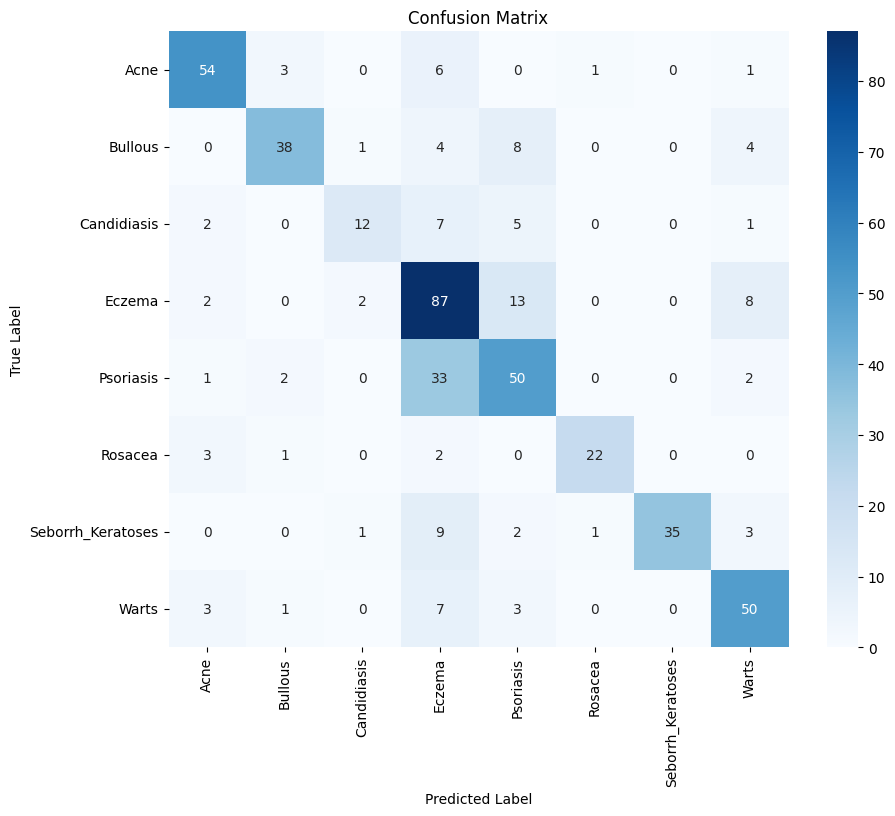

In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Save Model to Google Drive

In [ ]:
model.save('drive/MyDrive/model_t2.keras')